In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import time

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [21]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data / 255.0
y = mnist.target

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
X_train_small = X_train[:20000]
y_train_small = y_train[:20000]

In [24]:
start_time = time.time()

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_small, y_train_small)

end_time = time.time()

print(f"Training Time: {end_time - start_time:.2f} seconds")

Training Time: 21.25 seconds


In [25]:
y_pred = svm_model.predict(X_test)

In [26]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1371    1    1    0    1    2    2    0    2    1]
 [   1 1552    7    5    0    1    1    4    3    1]
 [   9    3 1350    4    6    0    6    8   10    2]
 [   2    3   10 1371    0   13    2   11   13    3]
 [   3    3    5    0 1313    0    8    2    0   31]
 [   4    0    2   11    1 1214   14    1   10    6]
 [  12    4    4    0    1    4 1345    0    5    0]
 [   2    6   12    1    8    0    0 1413    1   16]
 [   1    3    6    9    4   15    3    2 1315    7]
 [   6    9    1   13   26    3    1   15    7 1310]]


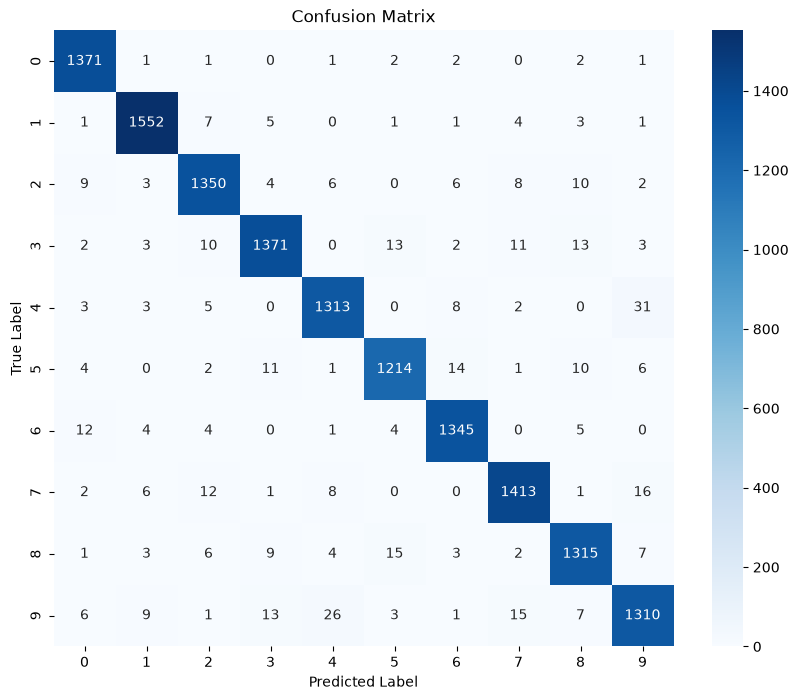

In [27]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [28]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.99      0.98      1575
           2       0.97      0.97      0.97      1398
           3       0.97      0.96      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.96      0.97      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.95      0.94      0.95      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



In [29]:
misclassified = np.where(y_test != y_pred)[0]

print("Total Misclassified:", len(misclassified))

Total Misclassified: 446


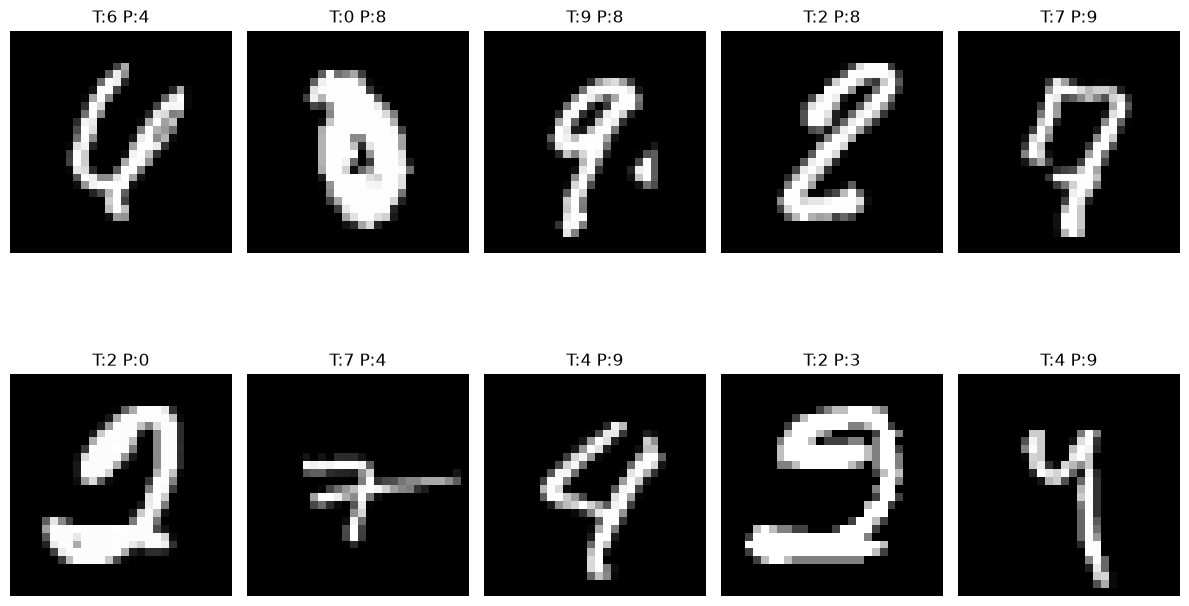

In [30]:
plt.figure(figsize=(12,8))

for i, index in enumerate(misclassified[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[index].reshape(28,28), cmap="gray")

    plt.title(f"T:{y_test[index]} P:{y_pred[index]}")

    plt.axis("off")

plt.tight_layout()

plt.show()

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9681


In [32]:
import pandas as pd

results = pd.DataFrame({
    "Model":["Logistic Regression","SVM (RBF)"],
    "Accuracy":[0.923,0.984]
})

results

,Model,Accuracy
0,Logistic Regression,0.923
1,SVM (RBF),0.984


In [33]:
plt.savefig("../images/confusion_matrix.png")

<Figure size 640x480 with 0 Axes>